# 5-2. Self-Corrective Modular RAG

## 실습 주제

`공직자_민원응대_핵심_매뉴얼.pdf` 데이터를 활용하여 **조건 분기와 재시도 루프가 있는 Modular RAG**를 구현한다.

5-1 노트북에서는 다음과 같은 선형 Modular RAG를 구현했다.

```text
START
→ classify_question
→ retrieve_manual
→ organize_evidence
→ generate_answer
→ validate_answer
→ END
```

이번 5-2 노트북에서는 검색 결과와 답변 품질을 평가한 뒤, 부족한 경우 다시 검색하거나 질문을 재작성하는 구조로 확장한다.

```text
사용자 질문
   ↓
Query Rewrite Node
   ↓
Retrieve Node
   ↓
Document Relevance Check Node
   ↓
관련 문서 충분?
   ├─ No → Query Rewrite Node로 재진입
   └─ Yes
        ↓
Evidence Organize Node
        ↓
Generate Answer Node
        ↓
Answer Evaluation Node
        ↓
답변 충분?
   ├─ No → Retrieve Node 또는 Query Rewrite Node
   └─ Yes → 최종 답변
```

## 학습 목표

- LangGraph의 `Conditional Edge`를 RAG 흐름에 적용한다.
- 검색 결과가 부족할 때 질문을 다시 작성하는 루프를 구현한다.
- 답변이 부족할 때 재검색 또는 재작성으로 흐름을 되돌린다.
- 단순 RAG와 Self-Corrective Modular RAG의 차이를 이해한다.

## 0. 실습 전제

- 데이터 파일: `../data/공직자_민원응대_핵심_매뉴얼.pdf`
- LLM: `z-ai/glm-5.3-flash` (NVIDIA)
- Embedding: `nvidia/nemotron-3-embed-1b` (NVIDIA)
- Vector DB: Qdrant 인메모리 모드
- 목표: 공직자 민원응대 매뉴얼 기반 질의응답 시스템 구현

> 이 노트북은 12번 실습 다음 단계로 사용할 수 있도록, `src` 파일 없이 노트북 안에서 전체 흐름을 구현한다.

In [2]:
from typing import Literal
from typing_extensions import TypedDict, NotRequired

from dotenv import load_dotenv

load_dotenv(override=True, dotenv_path="../../.env")

MAX_REWRITE_COUNT = 3
MAX_ANSWER_RETRY = 2

## 1. 벡터스토어 객체 생성

In [3]:
import os
from langchain_nvidia_ai_endpoints import NVIDIAEmbeddings
from langchain_qdrant import QdrantVectorStore

QDRANT_URL = "http://localhost:6333"
COLLECTION_NAME = "civil_complaint_manual_medium"

EMBEDDING_MODEL = "nvidia/nemotron-3-embed-1b"

embeddings = NVIDIAEmbeddings(model="nvidia/nemotron-3-embed-1b", api_key=os.getenv("nvidiaapi_key"))

vector_store = QdrantVectorStore.from_existing_collection(
    embedding=embeddings,
    collection_name=COLLECTION_NAME,
    url=QDRANT_URL,
)

c:\sk-encoa\llm_workspace\.venv\Lib\site-packages\langchain_nvidia_ai_endpoints\_common.py:250: UserWarning: Found nvidia/nemotron-3-embed-1b in available_models, but type is unknown and inference may fail.
  warnings.warn(


## 2. LLM 및 프롬프트 구성

이번 실습에서는 세 가지 판단/생성 프롬프트를 사용한다.

| 프롬프트 | 역할 |
|---|---|
| Query Rewrite Prompt | 질문을 검색에 적합한 질의로 재작성 |
| Document Grade Prompt | 검색된 문서가 질문에 답하기 충분한지 판단 |
| Answer Evaluation Prompt | 생성된 답변이 근거에 기반하고 충분한지 판단 |

In [4]:

from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

llm = ChatOpenAI(
    base_url="https://integrate.api.nvidia.com/v1",
    api_key=os.getenv("nvidiaapi_key"),
    model="z-ai/glm-5.3-flash",
    temperature=0,
)


query_rewrite_prompt = ChatPromptTemplate.from_messages([
    ("system", '''
당신은 공직자 민원응대 매뉴얼 검색 질의 생성기입니다.

역할:
- 사용자의 질문을 매뉴얼 검색에 적합한 질의로 바꿉니다.
- 민원응대 상황, 대응 절차, 보호조치, 법적 조치, 기록, 보고와 관련된 핵심어를 포함합니다.
- 너무 긴 문장보다 검색에 유리한 명사구 중심으로 작성합니다.

출력:
- 검색 질의만 한 줄로 출력하세요.
'''),
    ("human", '''
원 질문:
{question}

이전 검색 질의:
{previous_query}

이전 평가 결과:
{grade}

재작성 횟수:
{rewrite_count}
''')
])


document_grade_prompt = ChatPromptTemplate.from_messages([
    ("system", '''
당신은 RAG 검색 결과 평가자입니다.

검색된 문단이 사용자의 질문에 답하기 충분한지 판단하세요.

판단 기준:
- 질문의 핵심 상황과 직접 관련된 내용이 있는가?
- 대응 절차나 조치가 포함되어 있는가?
- 매뉴얼 근거로 답변을 만들 수 있는가?

출력 형식:
- 반드시 "충분:" 또는 "부족:"으로 시작하세요.
- 그 뒤에 한 문장으로 이유를 쓰세요.
'''),
    ("human", '''
질문:
{question}

검색 질의:
{rewritten_query}

검색 문단:
{context}
''')
])


evidence_prompt = ChatPromptTemplate.from_messages([
    ("system", '''
검색된 문단에서 질문 답변에 필요한 핵심 근거만 정리하세요.
문단에 없는 내용은 추가하지 마세요.
근거가 부족하면 부족하다고 명시하세요.
'''),
    ("human", '''
질문:
{question}

검색 문단:
{context}
''')
])


answer_prompt = ChatPromptTemplate.from_messages([
    ("system", '''
당신은 공직자 민원응대 매뉴얼 기반 업무지원 AI입니다.

규칙:
- 반드시 제공된 근거에 기반하여 답변하세요.
- 매뉴얼에 없는 내용은 추측하지 마세요.
- 민원응대 담당자가 현장에서 바로 참고할 수 있게 작성하세요.
- 위험 상황에서는 안전 확보, 보고, 기록, 보호조치를 우선합니다.

답변 형식:
1. 상황 판단
2. 즉시 대응
3. 단계별 조치
4. 민원인에게 사용할 수 있는 안내 표현
5. 담당자 보호조치
6. 주의사항
'''),
    ("human", '''
질문:
{question}

근거:
{evidence}
''')
])


answer_evaluation_prompt = ChatPromptTemplate.from_messages([
    ("system", '''
당신은 RAG 답변 검토자입니다.

답변이 다음 조건을 충족하는지 평가하세요.
- 질문에 직접 답하는가?
- 검색 근거에 기반하는가?
- 대응 절차가 충분히 구체적인가?
- 매뉴얼에 없는 내용을 추측하지 않았는가?

출력 형식:
- 반드시 "충분:", "부분충분:", "부족:" 중 하나로 시작하세요.
- 그 뒤에 한 문장으로 이유를 쓰세요.
'''),
    ("human", '''
질문:
{question}

검색 근거:
{context}

답변:
{answer}
''')
])


query_rewrite_chain = query_rewrite_prompt | llm | StrOutputParser()
document_grade_chain = document_grade_prompt | llm | StrOutputParser()
evidence_chain = evidence_prompt | llm | StrOutputParser()
answer_chain = answer_prompt | llm | StrOutputParser()
answer_evaluation_chain = answer_evaluation_prompt | llm | StrOutputParser()

## 3. 유틸 함수

검색 문서를 LLM에 전달하기 쉬운 문자열로 변환한다.

In [5]:
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END


def format_docs(docs: list[Document]) -> str:
    formatted = []

    for i, doc in enumerate(docs, start=1):
        formatted.append(
            f"[근거 {i}] page={doc.metadata.get('page')}, chunk={doc.metadata.get('chunk_id')}\n"
            f"{doc.page_content}"
        )

    return "\n\n".join(formatted)


def starts_with_sufficient(text: str) -> bool:
    return text.strip().startswith("충분")


def starts_with_insufficient(text: str) -> bool:
    return text.strip().startswith("부족")

## 4. State 정의

이번 실습에서는 루프 제어를 위해 `rewrite_count`, `answer_retry_count`를 추가한다.

| State 항목 | 의미 |
|---|---|
| question | 원 질문 |
| rewritten_query | 재작성된 검색 질의 |
| documents | 검색된 문서 |
| context | 검색 문서를 문자열로 정리한 내용 |
| document_grade | 검색 문서 충분성 평가 결과 |
| evidence | 답변 생성에 사용할 핵심 근거 |
| answer | 생성 답변 |
| answer_grade | 답변 품질 평가 결과 |
| rewrite_count | 질문 재작성 횟수 |
| answer_retry_count | 답변 재시도 횟수 |

In [6]:
class SelfCorrectiveRAGState(TypedDict):
    question: str
    rewritten_query: NotRequired[str]
    previous_query: NotRequired[str]
    documents: NotRequired[list[Document]]
    context: NotRequired[str]
    document_grade: NotRequired[str]
    evidence: NotRequired[str]
    answer: NotRequired[str]
    answer_grade: NotRequired[str]
    rewrite_count: NotRequired[int]
    answer_retry_count: NotRequired[int]

## 5. Node 정의

각 노드는 하나의 역할만 수행한다.

```text
query_rewrite_node
retrieve_manual_node
grade_documents_node
organize_evidence_node
generate_answer_node
evaluate_answer_node
```

In [7]:
# ── 노드 1: Query Rewrite ────────────────────────────
def query_rewrite_node(state: SelfCorrectiveRAGState) -> dict:
    rewrite_count = state.get("rewrite_count", 0)
    previous_query = state.get("rewritten_query", "")

    rewritten_query = query_rewrite_chain.invoke({
        "question": state["question"],
        "previous_query": previous_query,
        "grade": state.get("document_grade", ""),
        "rewrite_count": rewrite_count,
    }).strip()

    print(f"\n[Query Rewrite] rewrite_count={rewrite_count + 1}")
    print(rewritten_query)

    return {
        "previous_query": previous_query,
        "rewritten_query": rewritten_query,
        "rewrite_count": rewrite_count + 1,
    }

# ── 노드 2: 매뉴얼 검색 ──────────────────────────────
def retrieve_manual_node(state: SelfCorrectiveRAGState) -> dict:
    query = state.get("rewritten_query") or state["question"]

    # 재시도할수록 조금 더 많은 문서를 검색한다.
    answer_retry_count = state.get("answer_retry_count", 0)
    top_k = min(6, 4 + answer_retry_count)

    docs = vector_store.similarity_search(query, k=top_k)
    context = format_docs(docs)

    print(f"\n[Retrieve] top_k={top_k}")
    for doc in docs:
        print(f"- page={doc.metadata.get('page')}, chunk={doc.metadata.get('chunk_id')}")

    return {
        "documents": docs,
        "context": context,
    }

# ── 노드 3: 문서 평가 ─────────────────────────────────
def grade_documents_node(state: SelfCorrectiveRAGState) -> dict:
    grade = document_grade_chain.invoke({
        "question": state["question"],
        "rewritten_query": state["rewritten_query"],
        "context": state["context"],
    }).strip()

    print("\n[Document Grade]")
    print(grade)

    return {
        "document_grade": grade,
    }

# ── 노드 4: 근거 정리 ─────────────────────────────────
def organize_evidence_node(state: SelfCorrectiveRAGState) -> dict:
    evidence = evidence_chain.invoke({
        "question": state["question"],
        "context": state["context"],
    }).strip()

    print("\n[Evidence Organized]")
    print(evidence[:500])

    return {
        "evidence": evidence,
    }

# ── 노드 5: 답변 생성 ─────────────────────────────────
def generate_answer_node(state: SelfCorrectiveRAGState) -> dict:
    answer = answer_chain.invoke({
        "question": state["question"],
        "evidence": state["evidence"],
    }).strip()

    print("\n[Generate Answer]")
    print(answer[:500])

    return {
        "answer": answer,
    }

# ── 노드 6: 답변 평가 ─────────────────────────────────
def evaluate_answer_node(state: SelfCorrectiveRAGState) -> dict:
    answer_retry_count = state.get("answer_retry_count", 0)

    grade = answer_evaluation_chain.invoke({
        "question": state["question"],
        "context": state["context"],
        "answer": state["answer"],
    }).strip()

    print("\n[Answer Evaluation]")
    print(grade)

    return {
        "answer_grade": grade,
        "answer_retry_count": answer_retry_count + 1,
    }

## 6. Conditional Edge 함수 정의

검색 문서가 부족하면 `query_rewrite`로 되돌아간다.  
답변이 부족하면 재작성 또는 재검색으로 되돌아간다.

In [8]:
def starts_with_sufficient(text: str) -> bool:
    return text.strip().startswith("충분")

def route_after_document_grade(
    state: SelfCorrectiveRAGState
) -> Literal["organize_evidence", "query_rewrite"]:
    grade         = state.get("document_grade", "")
    rewrite_count = state.get("rewrite_count", 0)

    if starts_with_sufficient(grade):
        print("[Route] 문서 충분 → 근거 정리")
        return "organize_evidence"

    if rewrite_count < MAX_REWRITE_COUNT:
        print("[Route] 문서 부족 → 질문 재작성")
        return "query_rewrite"

    # 재작성 한도 도달 → 현재 문서로 최선의 답변 생성
    print("[Route] 재작성 한도 도달 → 현재 문서로 답변 생성")
    return "organize_evidence"

def route_after_answer_evaluation(
    state: SelfCorrectiveRAGState
) -> Literal["end", "query_rewrite", "retrieve_manual"]:
    answer_grade = state.get("answer_grade", "")
    rewrite_count = state.get("rewrite_count", 0)
    answer_retry_count = state.get("answer_retry_count", 0)

    if starts_with_sufficient(answer_grade):
        print("\n[Route] 답변 충분 → 종료")
        return "end"

    if answer_retry_count >= MAX_ANSWER_RETRY:
        print("\n[Route] 답변 재시도 한도 도달 → 종료")
        return "end"

    if rewrite_count < MAX_REWRITE_COUNT:
        print("\n[Route] 답변 부족 → 질문 재작성")
        return "query_rewrite"

    print("\n[Route] 답변 부족 → 검색 문서 확대")
    return "retrieve_manual"

## 7. Graph 구성

`add_conditional_edges()`를 사용하여 검색 평가와 답변 평가 이후의 흐름을 동적으로 결정한다.

In [9]:
graph = StateGraph(SelfCorrectiveRAGState)

graph.add_node("query_rewrite", query_rewrite_node)
graph.add_node("retrieve_manual", retrieve_manual_node)
graph.add_node("grade_documents", grade_documents_node)
graph.add_node("organize_evidence", organize_evidence_node)
graph.add_node("generate_answer", generate_answer_node)
graph.add_node("evaluate_answer", evaluate_answer_node)

graph.add_edge(START, "query_rewrite")
graph.add_edge("query_rewrite", "retrieve_manual")
graph.add_edge("retrieve_manual", "grade_documents")

graph.add_conditional_edges(
    "grade_documents",
    route_after_document_grade,
    {
        "organize_evidence": "organize_evidence",
        "query_rewrite": "query_rewrite",
    },
)

graph.add_edge("organize_evidence", "generate_answer")
graph.add_edge("generate_answer", "evaluate_answer")

graph.add_conditional_edges(
    "evaluate_answer",
    route_after_answer_evaluation,
    {
        "end": END,
        "query_rewrite": "query_rewrite",
        "retrieve_manual": "retrieve_manual",
    },
)

app = graph.compile()

## 8. 그래프 시각화

그래프를 시각화하면 이번 실습의 핵심인 루프 구조를 확인할 수 있다.

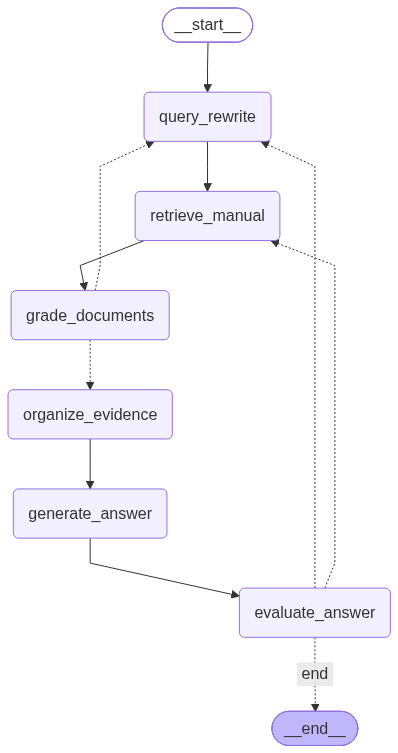

In [10]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

| 단계 | 노드                  | 핵심 의미           |
| -: | ------------------- | --------------- |
|  1 | `query_rewrite`     | 질문을 검색 친화적으로 바꿈 |
|  2 | `retrieve_manual`   | 매뉴얼에서 관련 문서 검색  |
|  3 | `grade_documents`   | 검색 문서가 충분한지 판단  |
|  4 | `organize_evidence` | 답변에 사용할 근거 정리   |
|  5 | `generate_answer`   | 근거 기반 답변 생성     |
|  6 | `evaluate_answer`   | 답변 품질 평가        |
|  7 | `end`               | 충분한 답변이면 종료     |


## 9. 실행 예제 1: 대면 폭행 민원 대응

폭행, 대면 민원, 안전 확보, 보고, 기록, 보호조치 등이 검색되어야 한다.

In [11]:
question = "대면 민원 중 민원인이 직원을 폭행하면 현장에서 어떻게 대응해야 하나요?"

result = app.invoke({
    "question": question,
    "rewrite_count": 0,
    "answer_retry_count": 0,
})

print("\n" + "=" * 80)
print("[최종 검색 질의]")
print(result.get("rewritten_query"))

print("\n[문서 평가]")
print(result.get("document_grade"))

print("\n[최종 답변]")
print(result.get("answer"))

print("\n[답변 평가]")
print(result.get("answer_grade"))


[Query Rewrite] rewrite_count=1
대면 민원인 폭행 현장 대응 절차 직원 보호조치 경찰 신고

[Retrieve] top_k=4
- page=10, chunk=17
- page=10, chunk=15
- page=10, chunk=16
- page=4, chunk=4

[Document Grade]
충분: 검색 문단에 대면 민원 중 폭행 발생 시 비상대응팀의 직원별 역할(민원인 제지·경고, 안전요원 호출, 경찰·119 신고, 녹화, 타 민원인 대피), 공무집행방해죄 경고 멘트, 피해직원 응급조치 및 휴게시간·심리상담 등 사후 조치까지 구체적으로 수록되어 있어 현장 대응 절차에 대한 답변을 만들기에 충분합니다.
[Route] 문서 충분 → 근거 정리

[Evidence Organized]
## 핵심 근거 정리

### 현장 대응 (핵심대응)

**기본 원칙** [근거 2]
- 비상대응팀(반)이 신속히 대응하여 **민원담당자 분리, 다른 민원인 대피, 경찰 신고**로 피해 최소화
- 녹화(음) 중이 아닐 경우 **즉시 녹화(음) 실시**

**비상대응팀 직원별 역할** [근거 1, 3]
- **팀장**: 민원인 제지 및 경고, 안전요원(경찰)과 동행
  - 경고멘트: "선생님, 공무원에 대한 폭행은 형법 제136조 공무집행방해죄에 해당되어 처벌받을 수 있습니다. 경찰에 신고하겠습니다."
- **팀원**: 안전요원 호출 및 경찰 신고, 피해자 상태확인(응급조치), 피해상태를 고려한 119 신고, 녹화 실시, 타 민원인 대피 등
- **퇴거 조치 시 유의사항** [근거 3]: 멘트로만 통보하고 신체접촉이 발생하지 않도록 유의
- 경찰 도착 전까지 민원인 진정 및 착석을 유도하는 등 **추가 피해 방지** [근거 1]

### 사후 조치

- 면담 후 **60분 이내 휴게시

[Generate Answer]
# 민원인 폭행 사태 현장 대응 매뉴얼

## 1. 상황 판단

- 대면 민원 중 민원인이 직원을 **폭행한 상황**으로, 단순 언어폭력·

## 10. 실행 예제 2: 반복 전화 민원 대응

반복 전화, 장시간 통화, 통화 종료 안내, 녹음, 상급자 보고 등 관련 근거를 검색하는지 확인한다.

In [ ]:
question = "같은 민원인이 계속 전화해서 같은 말을 반복하면 담당자는 어떻게 해야 하나요?"

result = app.invoke({
    "question": question,
    "rewrite_count": 0,
    "answer_retry_count": 0,
})

print("\n" + "=" * 80)
print("[최종 검색 질의]")
print(result.get("rewritten_query"))

print("\n[문서 평가]")
print(result.get("document_grade"))

print("\n[최종 답변]")
print(result.get("answer"))

print("\n[답변 평가]")
print(result.get("answer_grade"))


[Query Rewrite] rewrite_count=1
반복 민원 동일 민원인 전화 상담 대응 절차

[Retrieve] top_k=4
- page=8, chunk=10
- page=12, chunk=23
- page=17, chunk=33
- page=8, chunk=11


## 11. 실행 예제 3: 모호한 질문

질문이 모호할 때 Query Rewrite가 어떻게 검색 질의를 구체화하는지 확인한다.

In [ ]:
question = "민원인이 너무 심하게 굴면 어떻게 해야 해요?"

result = app.invoke({
    "question": question,
    "rewrite_count": 0,
    "answer_retry_count": 0,
})

print("\n" + "=" * 80)
print("[최종 검색 질의]")
print(result.get("rewritten_query"))

print("\n[문서 평가]")
print(result.get("document_grade"))

print("\n[최종 답변]")
print(result.get("answer"))

print("\n[답변 평가]")
print(result.get("answer_grade"))


[Query Rewrite] rewrite_count=1
민원인 심한 행동 대응 절차

[Retrieve] top_k=4
- page=10, chunk=17
- page=3, chunk=3
- page=3, chunk=2
- page=7, chunk=10

[Document Grade]
충분: 민원인의 심한 행동에 대한 대응 절차와 조치가 구체적으로 설명되어 있어, 민원인에게 경각심을 부여하고 법적 조치를 취할 수 있는 방법이 포함되어 있습니다.
[Route] 문서 충분 → 근거 정리

[Evidence Organized]
1. 민원인이 폭언을 할 경우, 전화나 대면에서 폭언에 준하여 대응하여 민원인에게 경각심을 부여해야 한다. (근거 1)
2. 정당한 사유 없이 반복 민원을 제기하는 경우, 민원처리법에 따라 종결 처리할 수 있으며, 최초 종결 처리 시 민원인에게 통지하고 이후 반복 민원은 처리 결과 회신 없이 종결할 수 있다. (근거 1)
3. 특이민원인으로부터 민원 담당자를 분리하고, 신체적·정신적 피해에 대한 치료 및 지원을 제공하며, 기관 차원의 법적 대응을 고려해야 한다. (근거 2)
4. 민원인의 폭언이나 폭행 등으로부터 민원 담당자를 보호하기 위한 사전 예방 조치를 취해야 한다. (근거 3)
5. 필요시 서면 경고문을 발송하고, 법적 조치 사항에 대해 법적 대응 전담부서와 협의해야 한다. (근거 4)

근거가 부족한 내용은 없습니다.

[Generate Answer]
1. 상황 판단  
민원인이 심하게 굴고 폭언을 하는 경우, 이는 민원인의 부적절한 행동으로 판단됩니다. 이러한 상황에서는 민원인의 경각심을 부여하고, 담당자의 안전을 확보하는 것이 중요합니다.

2. 즉시 대응  
민원인에게 정중하게 상황을 설명하고, 폭언이 계속될 경우 대응 조치를 취할 것임을 알립니다. 필요시 즉시 상급자에게 보고합니다.

3. 단계별 조치  
- 민원인에게 폭언을 중단할 것을 요청합니다.  
- 폭언이 계속될 경우, 서면 경고문을 발송할 수 있음을 안내합니다.

## 12. 수강생 실습 과제

아래 과제를 수행하면서 그래프의 흐름이 어떻게 바뀌는지 확인한다.

### 과제 1. 질문 바꿔보기

다음 질문으로 실행하고 검색 질의가 어떻게 재작성되는지 확인한다.

```text
민원인이 욕설을 하면서 전화를 끊지 않으면 어떻게 해야 하나요?
```

```text
민원인이 흉기를 들고 방문하면 담당자는 어떻게 대응해야 하나요?
```

```text
민원 응대 후 담당자가 심리적으로 힘들면 어떤 보호조치를 받을 수 있나요?
```

### 과제 2. 검색 문서 수 조정하기

`retrieve_manual_node()`의 `top_k` 값을 수정하여 결과가 어떻게 달라지는지 확인한다.

```python
top_k = min(6, 4 + answer_retry_count)
```

### 과제 3. 재작성 한도 바꿔보기

`MAX_REWRITE_COUNT` 값을 1, 2, 3으로 바꿔 보면서 루프 횟수가 어떻게 달라지는지 확인한다.

### 과제 4. 평가 기준 강화하기

`document_grade_prompt`와 `answer_evaluation_prompt`의 판단 기준을 더 엄격하게 바꿔 본다.

## 핵심 정리

```text
START
→ query_rewrite
→ retrieve_manual
→ grade_documents
   ├─ 부족 → query_rewrite
   └─ 충분 → organize_evidence
→ generate_answer
→ evaluate_answer
   ├─ 부족 → query_rewrite 또는 retrieve_manual
   └─ 충분 → END
```

이번 실습의 핵심은 다음과 같다.

1. Modular RAG는 각 기능을 독립 노드로 분리한다.
2. Self-Corrective Modular RAG는 검색 결과와 답변 결과를 평가한다.
3. 검색 문서가 부족하면 질문을 다시 작성한다.
4. 답변이 부족하면 재검색하거나 질문 재작성을 수행한다.
5. LangGraph의 `Conditional Edge`를 사용하면 RAG 흐름을 조건에 따라 제어할 수 있다.

12번 실습이 **선형 Modular RAG**라면, 13번 실습은 **루프가 있는 Self-Corrective Modular RAG**이다.